# Colab 1 — Analytical dataset construction for the article

This notebook organizes the anonymized dataset and generates a reproducible analytical cohort for the subsequent stages of the study.

## Objectives
1. Load and inspect the anonymized dataset.
2. Perform basic consistency checks.
3. Create derived variables useful for both the diagnostic section and the proposed method.
4. Build the equipment-year analytical cohort with future outcomes.
5. Export the final cohort for the next notebooks.

## Note
This notebook was designed to run in Google Colab.  
Upload the file `analytic_dataset_anonymized_equipment_year.csv` to the Colab environment and adjust the path below if necessary.

In [1]:
# ============================================
# 1) Imports and general configuration
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

DATA_PATH = "analytic_dataset_anonymized_equipment_year.csv"
EXPORT_PATH = "analytic_cohort_for_modeling.csv"

In [2]:
# ============================================
# 2) Load the dataset
# ============================================
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())
print(df.dtypes)

Shape: (20716, 21)


,equip_hash,hospital_hash,year,age_at_year,cm_count,total_downtime_hours,positive_downtime_count,max_downtime,any_downtime,brand_hash,model_hash,LEITOS_EXISTENTES_z,LEITOS_SUS_z,UTI_TOTAL_EXIST_z,UTI_TOTAL_SUS_z,UTI_ADULTO_EXIST_z,UTI_ADULTO_SUS_z,UTI_PEDIATRICO_EXIST_z,UTI_PEDIATRICO_SUS_z,UTI_NEONATAL_EXIST_z,UTI_NEONATAL_SUS_z
0,eq_f79f53558751,h_b4c7314b4322,2022,4.0,1.0,649.0,1.0,649.0,1,b_293446a1fb5f,m_659c5b813a28,-1.792915,-1.676168,-1.410737,-1.193491,-0.681331,-0.616148,-0.872628,-0.872628,-1.503517,-1.474097
1,eq_f79f53558751,h_b4c7314b4322,2023,5.0,0.0,0.0,0.0,0.0,0,b_293446a1fb5f,m_659c5b813a28,-1.464609,-1.333432,-1.631543,-1.227115,-0.751839,-0.607457,-0.893161,-0.890962,-1.504843,-1.480203
2,eq_f79f53558751,h_b4c7314b4322,2024,6.0,2.0,2072.0,2.0,2028.0,1,b_293446a1fb5f,m_659c5b813a28,-1.367755,-1.271910,-1.841277,-1.410218,-0.839424,-0.661581,-1.210405,-1.014119,-1.539650,-1.534416
3,eq_f79f53558751,h_b4c7314b4322,2025,7.0,0.0,0.0,0.0,0.0,0,b_293446a1fb5f,m_659c5b813a28,-1.376272,-1.303249,-1.763270,-1.458160,-0.827817,-0.646279,-1.209684,-1.202892,-1.553350,-1.541123
4,eq_ae959a5d8205,h_b4c7314b4322,2022,4.0,1.0,6.0,1.0,6.0,1,b_293446a1fb5f,m_9589e2ef8ef2,-1.792915,-1.676168,-1.410737,-1.193491,-0.681331,-0.616148,-0.872628,-0.872628,-1.503517,-1.474097


equip_hash                  object
hospital_hash               object
year                         int64
age_at_year                float64
cm_count                   float64
total_downtime_hours       float64
positive_downtime_count    float64
max_downtime               float64
any_downtime                 int64
brand_hash                  object
model_hash                  object
LEITOS_EXISTENTES_z        float64
LEITOS_SUS_z               float64
UTI_TOTAL_EXIST_z          float64
UTI_TOTAL_SUS_z            float64
UTI_ADULTO_EXIST_z         float64
UTI_ADULTO_SUS_z           float64
UTI_PEDIATRICO_EXIST_z     float64
UTI_PEDIATRICO_SUS_z       float64
UTI_NEONATAL_EXIST_z       float64
UTI_NEONATAL_SUS_z         float64
dtype: object


## Expected structure
The dataset is expected to contain, at minimum, the following fields:

- `equip_hash`
- `hospital_hash`
- `year`
- `age_at_year`
- `cm_count`
- `total_downtime_hours`
- `positive_downtime_count`
- `max_downtime`
- `any_downtime`
- `brand_hash`
- `model_hash`

as well as anonymized and normalized hospital-level CNES variables.

In [3]:
# ============================================
# 3) Basic consistency checks
# ============================================
required_cols = [
    "equip_hash", "hospital_hash", "year", "age_at_year",
    "cm_count", "total_downtime_hours", "positive_downtime_count",
    "max_downtime", "any_downtime", "brand_hash", "model_hash"
]

missing_required = [c for c in required_cols if c not in df.columns]
assert not missing_required, f"Missing columns: {missing_required}"

print("Available years:", sorted(df["year"].dropna().unique().tolist()))
print("Number of hospitals:", df["hospital_hash"].nunique())
print("Number of equipment units:", df["equip_hash"].nunique())
print("Number of brands:", df["brand_hash"].nunique())
print("Number of models:", df["model_hash"].nunique())

print("\nMissing values by column:")
display(df.isna().sum().sort_values(ascending=False))

Available years: [2022, 2023, 2024, 2025]
Number of hospitals: 39
Number of equipment units: 5907
Number of brands: 36
Number of models: 143

Missing values by column:


,0
equip_hash,0
hospital_hash,0
year,0
age_at_year,0
cm_count,0
total_downtime_hours,0
positive_downtime_count,0
max_downtime,0
any_downtime,0
brand_hash,0


In [4]:
# ============================================
# 4) Light cleaning and standardization
# ============================================
numeric_cols = [
    "age_at_year", "cm_count", "total_downtime_hours",
    "positive_downtime_count", "max_downtime", "any_downtime"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Ensure temporal ordering within each equipment trajectory
df = df.sort_values(["equip_hash", "year"]).reset_index(drop=True)

# Defensive clipping for non-negative operational variables
df["cm_count"] = df["cm_count"].clip(lower=0)
df["total_downtime_hours"] = df["total_downtime_hours"].clip(lower=0)
df["positive_downtime_count"] = df["positive_downtime_count"].clip(lower=0)
df["max_downtime"] = df["max_downtime"].clip(lower=0)

display(df.head())

,equip_hash,hospital_hash,year,age_at_year,cm_count,total_downtime_hours,positive_downtime_count,max_downtime,any_downtime,brand_hash,model_hash,LEITOS_EXISTENTES_z,LEITOS_SUS_z,UTI_TOTAL_EXIST_z,UTI_TOTAL_SUS_z,UTI_ADULTO_EXIST_z,UTI_ADULTO_SUS_z,UTI_PEDIATRICO_EXIST_z,UTI_PEDIATRICO_SUS_z,UTI_NEONATAL_EXIST_z,UTI_NEONATAL_SUS_z
0,eq_00308ddbf02c,h_87a15588f3d1,2025,0.0,0.0,0.0,0.0,0.0,0,b_b5582bab280c,m_0f2cb0e1a162,-0.165465,-0.469573,-0.377743,-0.430190,-0.066824,-0.237408,-1.209684,-1.202892,0.325281,0.345604
1,eq_00339a54eaa6,h_f3391264376f,2022,2.0,0.0,0.0,0.0,0.0,0,b_b5582bab280c,m_0f2cb0e1a162,1.163034,1.173656,1.139074,0.934462,0.501098,0.560743,1.321094,1.321094,1.064779,1.121053
2,eq_00339a54eaa6,h_f3391264376f,2023,3.0,0.0,0.0,0.0,0.0,0,b_b5582bab280c,m_0f2cb0e1a162,1.189540,1.214732,1.015032,0.933842,-0.184465,-0.090361,1.275125,1.305313,1.105163,1.141548
3,eq_00339a54eaa6,h_f3391264376f,2024,4.0,1.0,186.0,1.0,186.0,1,b_b5582bab280c,m_0f2cb0e1a162,1.086737,1.125939,0.810040,0.865332,-0.289683,-0.150083,0.934306,1.132643,1.069034,1.079456
4,eq_00339a54eaa6,h_f3391264376f,2025,5.0,1.0,27.0,1.0,27.0,1,b_b5582bab280c,m_0f2cb0e1a162,0.949819,0.985986,0.747902,0.809978,-0.306104,-0.152328,0.927215,0.960698,1.049722,1.073167


## Derived variables
The features below serve two purposes:
1. to support the motivating empirical diagnostics;
2. to provide the analytical basis for the proposed method and the benchmark models.

These transformations are intended to handle asymmetry in scale and to capture basic temporal persistence.

In [5]:
# ============================================
# 5) Derived features
# ============================================
eps = 1e-6

# Log-transformations for skewed operational variables
df["log_cm_count"] = np.log1p(df["cm_count"])
df["log_total_downtime"] = np.log1p(df["total_downtime_hours"])
df["log_max_downtime"] = np.log1p(df["max_downtime"])

# Simple intensity measures
df["downtime_per_cm"] = np.where(
    df["cm_count"] > 0,
    df["total_downtime_hours"] / (df["cm_count"] + eps),
    0.0
)
df["log_downtime_per_cm"] = np.log1p(df["downtime_per_cm"])

df["downtime_event_intensity"] = np.where(
    df["positive_downtime_count"] > 0,
    df["total_downtime_hours"] / (df["positive_downtime_count"] + eps),
    0.0
)
df["log_downtime_event_intensity"] = np.log1p(df["downtime_event_intensity"])

# Age bands for descriptive tables and diagnostic figures
df["age_band"] = pd.cut(
    df["age_at_year"],
    bins=[-np.inf, 5, 10, 15, 20, np.inf],
    labels=["<=5", "6-10", "11-15", "16-20", ">20"]
)

# Lagged operational history by equipment
group = df.groupby("equip_hash", sort=False)

df["cm_count_lag1"] = group["cm_count"].shift(1)
df["total_downtime_lag1"] = group["total_downtime_hours"].shift(1)
df["any_downtime_lag1"] = group["any_downtime"].shift(1)
df["age_lag1"] = group["age_at_year"].shift(1)

# Expanding historical means up to t-1
df["cm_count_expanding_mean_lag1"] = (
    group["cm_count"]
    .apply(lambda s: s.shift(1).expanding().mean())
    .reset_index(level=0, drop=True)
)

df["downtime_expanding_mean_lag1"] = (
    group["total_downtime_hours"]
    .apply(lambda s: s.shift(1).expanding().mean())
    .reset_index(level=0, drop=True)
)

# Simple year-to-year changes
df["delta_cm_vs_lag1"] = df["cm_count"] - df["cm_count_lag1"]
df["delta_downtime_vs_lag1"] = df["total_downtime_hours"] - df["total_downtime_lag1"]

display(df.head(10))

,equip_hash,hospital_hash,year,age_at_year,cm_count,total_downtime_hours,positive_downtime_count,max_downtime,any_downtime,brand_hash,model_hash,LEITOS_EXISTENTES_z,LEITOS_SUS_z,UTI_TOTAL_EXIST_z,UTI_TOTAL_SUS_z,UTI_ADULTO_EXIST_z,UTI_ADULTO_SUS_z,UTI_PEDIATRICO_EXIST_z,UTI_PEDIATRICO_SUS_z,UTI_NEONATAL_EXIST_z,UTI_NEONATAL_SUS_z,log_cm_count,log_total_downtime,log_max_downtime,downtime_per_cm,log_downtime_per_cm,downtime_event_intensity,log_downtime_event_intensity,age_band,cm_count_lag1,total_downtime_lag1,any_downtime_lag1,age_lag1,cm_count_expanding_mean_lag1,downtime_expanding_mean_lag1,delta_cm_vs_lag1,delta_downtime_vs_lag1
0,eq_00308ddbf02c,h_87a15588f3d1,2025,0.0,0.0,0.0,0.0,0.0,0,b_b5582bab280c,m_0f2cb0e1a162,-0.165465,-0.469573,-0.377743,-0.430190,-0.066824,-0.237408,-1.209684,-1.202892,0.325281,0.345604,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<=5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,eq_00339a54eaa6,h_f3391264376f,2022,2.0,0.0,0.0,0.0,0.0,0,b_b5582bab280c,m_0f2cb0e1a162,1.163034,1.173656,1.139074,0.934462,0.501098,0.560743,1.321094,1.321094,1.064779,1.121053,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<=5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,eq_00339a54eaa6,h_f3391264376f,2023,3.0,0.0,0.0,0.0,0.0,0,b_b5582bab280c,m_0f2cb0e1a162,1.189540,1.214732,1.015032,0.933842,-0.184465,-0.090361,1.275125,1.305313,1.105163,1.141548,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<=5,0.0,0.0,0.0,2.0,0.000000,0.0,0.0,0.0
3,eq_00339a54eaa6,h_f3391264376f,2024,4.0,1.0,186.0,1.0,186.0,1,b_b5582bab280c,m_0f2cb0e1a162,1.086737,1.125939,0.810040,0.865332,-0.289683,-0.150083,0.934306,1.132643,1.069034,1.079456,0.693147,5.231109,5.231109,185.999814,5.231108,185.999814,5.231108,<=5,0.0,0.0,0.0,3.0,0.000000,0.0,1.0,186.0
4,eq_00339a54eaa6,h_f3391264376f,2025,5.0,1.0,27.0,1.0,27.0,1,b_b5582bab280c,m_0f2cb0e1a162,0.949819,0.985986,0.747902,0.809978,-0.306104,-0.152328,0.927215,0.960698,1.049722,1.073167,0.693147,3.332205,3.332205,26.999973,3.332204,26.999973,3.332204,<=5,1.0,186.0,1.0,4.0,0.333333,62.0,0.0,-159.0
5,eq_0044d3ea0082,h_b052b2239a62,2023,0.0,0.0,0.0,0.0,0.0,0,b_293446a1fb5f,m_5e06c8e5a3cd,-0.467852,-0.376477,-1.022215,-0.729593,-0.184465,-0.090361,-0.893161,-0.890962,-1.504843,-1.480203,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<=5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,eq_0044d3ea0082,h_b052b2239a62,2024,1.0,0.0,0.0,0.0,0.0,0,b_293446a1fb5f,m_5e06c8e5a3cd,-0.527059,-0.450616,-1.230858,-0.886312,-0.289683,-0.150083,-1.210405,-1.014119,-1.539650,-1.534416,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<=5,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
7,eq_0044d3ea0082,h_b052b2239a62,2025,2.0,1.0,4.0,1.0,4.0,1,b_293446a1fb5f,m_5e06c8e5a3cd,-0.549145,-0.499126,-1.091573,-0.935961,-0.221692,-0.152328,-1.209684,-1.202892,-1.553350,-1.541123,0.693147,1.609438,1.609438,3.999996,1.609437,3.999996,1.609437,<=5,0.0,0.0,0.0,1.0,0.000000,0.0,1.0,4.0
8,eq_0058a4d9abc8,h_8d66861c1987,2022,4.0,0.0,0.0,0.0,0.0,0,b_150edee60925,m_2b11a4a88688,1.058258,1.059296,-0.490537,-0.348005,-0.681331,-0.616148,-0.872628,-0.872628,0.519298,0.569868,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<=5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,eq_0058a4d9abc8,h_8d66861c1987,2023,5.0,0.0,0.0,0.0,0.0,0,b_150edee60925,m_2b11a4a88688,0.431179,0.486654,-0.579996,-0.368516,-0.751839,-0.607457,-0.893161,-0.890962,0.550823,0.584714,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<=5,0.0,0.0,0.0,4.0,0.000000,0.0,0.0,0.0


In [6]:
# ============================================
# 6) Construction of future outcomes
# ============================================
# Future outcomes at t+1 for each equipment unit
df["cm_count_t_plus_1"] = group["cm_count"].shift(-1)
df["downtime_t_plus_1"] = group["total_downtime_hours"].shift(-1)
df["any_downtime_t_plus_1"] = group["any_downtime"].shift(-1)

# Future high-downtime outcome:
# defined using the 75th percentile of observed t+1 downtime
future_downtime = df["downtime_t_plus_1"].dropna()
high_downtime_threshold = future_downtime.quantile(0.75)

df["high_downtime_t_plus_1"] = np.where(
    df["downtime_t_plus_1"].notna(),
    (df["downtime_t_plus_1"] >= high_downtime_threshold).astype(int),
    np.nan
)

print("High future downtime threshold (P75 of t+1 downtime):", high_downtime_threshold)
display(df[[
    "equip_hash", "year", "cm_count", "total_downtime_hours",
    "cm_count_t_plus_1", "downtime_t_plus_1", "high_downtime_t_plus_1"
]].head(10))

High future downtime threshold (P75 of t+1 downtime): 66.0


,equip_hash,year,cm_count,total_downtime_hours,cm_count_t_plus_1,downtime_t_plus_1,high_downtime_t_plus_1
0,eq_00308ddbf02c,2025,0.0,0.0,NaN,NaN,NaN
1,eq_00339a54eaa6,2022,0.0,0.0,0.0,0.0,0.0
2,eq_00339a54eaa6,2023,0.0,0.0,1.0,186.0,1.0
3,eq_00339a54eaa6,2024,1.0,186.0,1.0,27.0,0.0
4,eq_00339a54eaa6,2025,1.0,27.0,NaN,NaN,NaN
5,eq_0044d3ea0082,2023,0.0,0.0,0.0,0.0,0.0
6,eq_0044d3ea0082,2024,0.0,0.0,1.0,4.0,0.0
7,eq_0044d3ea0082,2025,1.0,4.0,NaN,NaN,NaN
8,eq_0058a4d9abc8,2022,0.0,0.0,0.0,0.0,0.0
9,eq_0058a4d9abc8,2023,0.0,0.0,0.0,0.0,0.0


## Main analytical cohort
The main modeling cohort should contain only rows for which the future outcome is observed.
In practice, this usually excludes the last available year for each equipment unit.

In [7]:
# ============================================
# 7) Main analytical cohort
# ============================================
analytic = df[df["downtime_t_plus_1"].notna()].copy()

print("Analytical cohort shape:", analytic.shape)
print("Number of equipment units:", analytic["equip_hash"].nunique())
print("Number of hospitals:", analytic["hospital_hash"].nunique())
print("Proportion of future high downtime:",
      analytic["high_downtime_t_plus_1"].mean())

display(analytic.head())

Analytical cohort shape: (14809, 41)
Number of equipment units: 5503
Number of hospitals: 39
Proportion of future high downtime: 0.25045580390303196


,equip_hash,hospital_hash,year,age_at_year,cm_count,total_downtime_hours,positive_downtime_count,max_downtime,any_downtime,brand_hash,model_hash,LEITOS_EXISTENTES_z,LEITOS_SUS_z,UTI_TOTAL_EXIST_z,UTI_TOTAL_SUS_z,UTI_ADULTO_EXIST_z,UTI_ADULTO_SUS_z,UTI_PEDIATRICO_EXIST_z,UTI_PEDIATRICO_SUS_z,UTI_NEONATAL_EXIST_z,UTI_NEONATAL_SUS_z,log_cm_count,log_total_downtime,log_max_downtime,downtime_per_cm,log_downtime_per_cm,downtime_event_intensity,log_downtime_event_intensity,age_band,cm_count_lag1,total_downtime_lag1,any_downtime_lag1,age_lag1,cm_count_expanding_mean_lag1,downtime_expanding_mean_lag1,delta_cm_vs_lag1,delta_downtime_vs_lag1,cm_count_t_plus_1,downtime_t_plus_1,any_downtime_t_plus_1,high_downtime_t_plus_1
1,eq_00339a54eaa6,h_f3391264376f,2022,2.0,0.0,0.0,0.0,0.0,0,b_b5582bab280c,m_0f2cb0e1a162,1.163034,1.173656,1.139074,0.934462,0.501098,0.560743,1.321094,1.321094,1.064779,1.121053,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<=5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
2,eq_00339a54eaa6,h_f3391264376f,2023,3.0,0.0,0.0,0.0,0.0,0,b_b5582bab280c,m_0f2cb0e1a162,1.189540,1.214732,1.015032,0.933842,-0.184465,-0.090361,1.275125,1.305313,1.105163,1.141548,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<=5,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,186.0,1.0,1.0
3,eq_00339a54eaa6,h_f3391264376f,2024,4.0,1.0,186.0,1.0,186.0,1,b_b5582bab280c,m_0f2cb0e1a162,1.086737,1.125939,0.810040,0.865332,-0.289683,-0.150083,0.934306,1.132643,1.069034,1.079456,0.693147,5.231109,5.231109,185.999814,5.231108,185.999814,5.231108,<=5,0.0,0.0,0.0,3.0,0.0,0.0,1.0,186.0,1.0,27.0,1.0,0.0
5,eq_0044d3ea0082,h_b052b2239a62,2023,0.0,0.0,0.0,0.0,0.0,0,b_293446a1fb5f,m_5e06c8e5a3cd,-0.467852,-0.376477,-1.022215,-0.729593,-0.184465,-0.090361,-0.893161,-0.890962,-1.504843,-1.480203,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<=5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
6,eq_0044d3ea0082,h_b052b2239a62,2024,1.0,0.0,0.0,0.0,0.0,0,b_293446a1fb5f,m_5e06c8e5a3cd,-0.527059,-0.450616,-1.230858,-0.886312,-0.289683,-0.150083,-1.210405,-1.014119,-1.539650,-1.534416,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<=5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,1.0,0.0


,age_band,n,mean_cm,mean_downtime,future_high_downtime_rate
0,<=5,8408,0.688273,265.637607,0.232160
1,6-10,3749,0.951454,368.919178,0.264604
2,11-15,2034,1.240905,293.446411,0.302852
3,16-20,358,1.569832,215.639665,0.282123
4,>20,260,0.588462,277.965385,0.184615


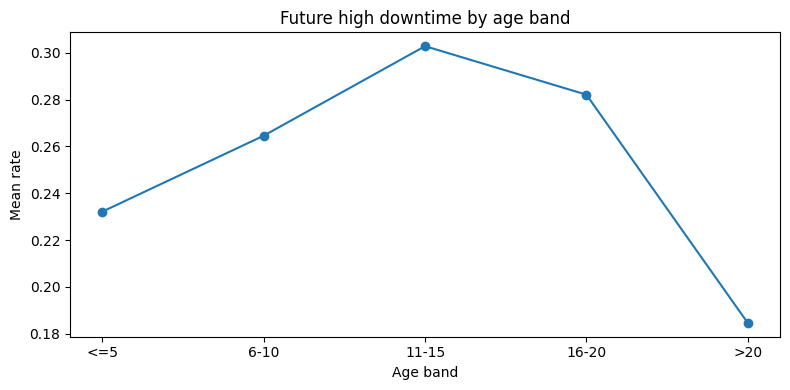

In [8]:
# ============================================
# 8) Initial diagnostic summary
# ============================================
summary_by_age = analytic.groupby("age_band", observed=False).agg(
    n=("equip_hash", "size"),
    mean_cm=("cm_count", "mean"),
    mean_downtime=("total_downtime_hours", "mean"),
    future_high_downtime_rate=("high_downtime_t_plus_1", "mean")
).reset_index()

display(summary_by_age)

plt.figure(figsize=(8, 4))
plt.plot(summary_by_age["age_band"].astype(str), summary_by_age["future_high_downtime_rate"], marker="o")
plt.title("Future high downtime by age band")
plt.xlabel("Age band")
plt.ylabel("Mean rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
# ============================================
# 9) Preliminary heterogeneity by brand and hospital
# ============================================
brand_summary = (
    analytic.groupby("brand_hash")
    .agg(
        n=("equip_hash", "size"),
        mean_cm=("cm_count", "mean"),
        mean_downtime=("total_downtime_hours", "mean"),
        future_high_downtime_rate=("high_downtime_t_plus_1", "mean")
    )
    .sort_values("future_high_downtime_rate", ascending=False)
)

hospital_summary = (
    analytic.groupby("hospital_hash")
    .agg(
        n=("equip_hash", "size"),
        mean_cm=("cm_count", "mean"),
        mean_downtime=("total_downtime_hours", "mean"),
        future_high_downtime_rate=("high_downtime_t_plus_1", "mean")
    )
    .sort_values("future_high_downtime_rate", ascending=False)
)

print("Top 10 brands by future high-downtime rate")
display(brand_summary.head(10))

print("Top 10 hospitals by future high-downtime rate")
display(hospital_summary.head(10))

Top 10 brands by future high-downtime rate


,n,mean_cm,mean_downtime,future_high_downtime_rate
brand_hash,,,,
b_e2e2917b1e32,1,2.000000,1.000000,1.000000
b_0f1d0f827474,18,3.277778,1157.888889,0.722222
b_6b3725d0d45d,43,1.790698,447.069767,0.534884
b_9a6bf9295f3d,195,1.441026,450.856410,0.374359
b_865015c653a8,105,0.847619,122.342857,0.323810
b_da80075e3434,240,1.404167,119.354167,0.308333
b_af56f90db2f0,39,0.794872,140.384615,0.307692
b_ed9adb9799e9,33,0.727273,566.242424,0.303030
b_31a19c993a76,54,1.185185,89.388889,0.296296


Top 10 hospitals by future high-downtime rate


,n,mean_cm,mean_downtime,future_high_downtime_rate
hospital_hash,,,,
h_98004e5f5a8f,377,1.477454,1186.978780,0.615385
h_9a2bfa5dd4b6,126,2.253968,135.634921,0.515873
h_d90e01eb9931,629,1.187599,359.796502,0.494436
h_2cc501c53d90,246,1.126016,325.223577,0.422764
h_87a15588f3d1,292,1.513699,461.732877,0.414384
h_e41ff37e36a1,228,1.078947,537.434211,0.412281
h_4268c4662dae,249,3.020080,367.389558,0.409639
h_a361c6f93235,51,0.313725,1862.176471,0.392157
h_12dcdfb79130,492,1.758130,400.678862,0.382114


In [10]:
# ============================================
# 10) Export analytical cohort
# ============================================
analytic.to_csv(EXPORT_PATH, index=False)
print("Exported file:", EXPORT_PATH)
print("Final columns:", analytic.columns.tolist())

Exported file: analytic_cohort_for_modeling.csv
Final columns: ['equip_hash', 'hospital_hash', 'year', 'age_at_year', 'cm_count', 'total_downtime_hours', 'positive_downtime_count', 'max_downtime', 'any_downtime', 'brand_hash', 'model_hash', 'LEITOS_EXISTENTES_z', 'LEITOS_SUS_z', 'UTI_TOTAL_EXIST_z', 'UTI_TOTAL_SUS_z', 'UTI_ADULTO_EXIST_z', 'UTI_ADULTO_SUS_z', 'UTI_PEDIATRICO_EXIST_z', 'UTI_PEDIATRICO_SUS_z', 'UTI_NEONATAL_EXIST_z', 'UTI_NEONATAL_SUS_z', 'log_cm_count', 'log_total_downtime', 'log_max_downtime', 'downtime_per_cm', 'log_downtime_per_cm', 'downtime_event_intensity', 'log_downtime_event_intensity', 'age_band', 'cm_count_lag1', 'total_downtime_lag1', 'any_downtime_lag1', 'age_lag1', 'cm_count_expanding_mean_lag1', 'downtime_expanding_mean_lag1', 'delta_cm_vs_lag1', 'delta_downtime_vs_lag1', 'cm_count_t_plus_1', 'downtime_t_plus_1', 'any_downtime_t_plus_1', 'high_downtime_t_plus_1']


## Next notebooks
### Colab 2 — Motivating empirical evidence
- figures and tables for age, brand/model, and hospital-level heterogeneity;
- simple tests and visual diagnostics that motivate the proposed method.

### Colab 3 — Proposed method and benchmarks
- latent deterioration model;
- Bayesian decision rule;
- GLMM, XGBoost, and heuristic baselines;
- hospital-level validation;
- loss-based simulation scenarios.